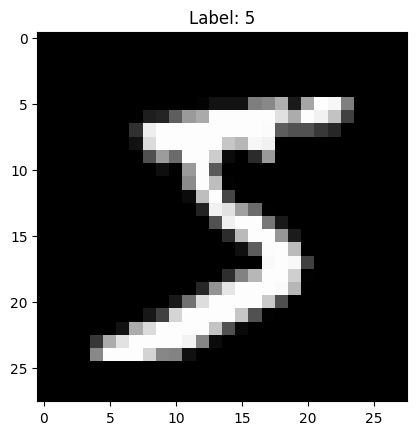

Original label: 0
One-hot encoded label: [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Epoch 1, Batch 0, Loss: 2.3043
Epoch 1, Batch 100, Loss: 2.2984
Epoch 1, Batch 200, Loss: 2.2961
Epoch 1, Batch 300, Loss: 2.2880
Epoch 1, Batch 400, Loss: 2.3115
Epoch 1, Batch 500, Loss: 2.2995
Epoch 1, Batch 600, Loss: 2.3054
Epoch 1, Batch 700, Loss: 2.3085
Epoch 2, Batch 0, Loss: 2.3009
Epoch 2, Batch 100, Loss: 2.3074
Epoch 2, Batch 200, Loss: 2.3001
Epoch 2, Batch 300, Loss: 2.3031
Epoch 2, Batch 400, Loss: 2.3020
Epoch 2, Batch 500, Loss: 2.2917
Epoch 2, Batch 600, Loss: 2.3012
Epoch 2, Batch 700, Loss: 2.3101
Epoch 3, Batch 0, Loss: 2.3089
Epoch 3, Batch 100, Loss: 2.2946
Epoch 3, Batch 200, Loss: 2.2998
Epoch 3, Batch 300, Loss: 2.3008
Epoch 3, Batch 400, Loss: 2.3062
Epoch 3, Batch 500, Loss: 2.3078
Epoch 3, Batch 600, Loss: 2.3046
Epoch 3, Batch 700, Loss: 2.3026
Epoch 4, Batch 0, Loss: 2.2926
Epoch 4, Batch 100, Loss: 2.2992
Epoch 4, Batch 200, Loss: 2.2942
Epoch 4, Batch 300, Loss: 2.2882
Epoch 4, Ba

In [3]:
#Need to learn backprop from scratch
#Will write every single function every single gradient without pytorch
#First, lets import numpy and matplotlib
import numpy as np
import matplotlib.pyplot as plt
#Now, lets import a simple dataset, the MNIST dataset
from sklearn.datasets import fetch_openml
mnist = fetch_openml('mnist_784', version=1)
X = mnist.data.values   # convert from pandas DataFrame to numpy array
y = mnist.target.values # convert from pandas Series to numpy array
#Print a sample image
plt.imshow(X[0].reshape(28, 28), cmap='gray')
plt.title(f'Label: {y[0]}')
plt.show()#Now, lets normalize the data
X = X / 255.0
#Now, lets split the data into training validation and test, 70 15 15
#Ensure balanced classes in each split
from sklearn.model_selection import train_test_split
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)
#Now, lets convert the labels to integers
y_train = y_train.astype(int)
y_val = y_val.astype(int)
y_test = y_test.astype(int)
#Now, lets one-hot encode the labels
#one-hot encoding is a way to represent categorical variables as binary vectors
#For example, if we have 10 classes, we can represent the label 3 as [0, 0, 0, 1, 0, 0, 0, 0, 0, 0]
def one_hot_encode(labels, num_classes):
    one_hot = np.zeros((labels.shape[0], num_classes))
    one_hot[np.arange(labels.shape[0]), labels] = 1
    return one_hot
y_train_one_hot = one_hot_encode(y_train, 10)
y_val_one_hot = one_hot_encode(y_val, 10)
y_test_one_hot = one_hot_encode(y_test, 10)
#Print a sample one-hot encoded label
print(f'Original label: {y_train[0]}')
print(f'One-hot encoded label: {y_train_one_hot[0]}')
#Now, lets define the architecture of our neural network
#We will use a simple MLP, 3 hidden layers with sigmoid activation functions
#and an output layer with softmax activation function
input_size = 784 #28*28 because each image is 28x28 pixels
hidden_size1 = 128
hidden_size2 = 64
hidden_size3 = 32
output_size = 10 #10 classes for digits 0-9
#Now, lets initialize the weights and biases for each layer
def initialize_weights(input_size, hidden_size1, hidden_size2, hidden_size3, output_size):
    weights = {
        'W1': np.random.randn(input_size, hidden_size1) * 0.01,
        'b1': np.zeros((1, hidden_size1)),
        'W2': np.random.randn(hidden_size1, hidden_size2) * 0.01,
        'b2': np.zeros((1, hidden_size2)),
        'W3': np.random.randn(hidden_size2, hidden_size3) * 0.01,
        'b3': np.zeros((1, hidden_size3)),
        'W4': np.random.randn(hidden_size3, output_size) * 0.01,
        'b4': np.zeros((1, output_size))
    }
    return weights
weights = initialize_weights(input_size, hidden_size1, hidden_size2, hidden_size3, output_size)
#Now, lets define the activation functions
def sigmoid(z):
    return 1 / (1 + np.exp(-z))
def sigmoid_derivative(z):
    s = sigmoid(z)
    return s * (1 - s)
def softmax(z):
    exp_z = np.exp(z - np.max(z, axis=1, keepdims=True)) #for numerical stability
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)
#Now, lets define the forward pass
def forward_pass(X, weights): #X is the input data, weights is the dictionary of weights and biases
    Z1 = np.dot(X, weights['W1']) + weights['b1']
    A1 = sigmoid(Z1)
    Z2 = np.dot(A1, weights['W2']) + weights['b2']
    A2 = sigmoid(Z2)
    Z3 = np.dot(A2, weights['W3']) + weights['b3']
    A3 = sigmoid(Z3)
    Z4 = np.dot(A3, weights['W4']) + weights['b4']
    A4 = softmax(Z4)
    cache = {
        'Z1': Z1, 'A1': A1,
        'Z2': Z2, 'A2': A2,
        'Z3': Z3, 'A3': A3,
        'Z4': Z4, 'A4': A4
    }
    return A4, cache

# Cross-Entropy Loss
def compute_loss(A4, y_one_hot):
    N = A4.shape[0]                              # number of samples in the batch

    log_probs = np.log(A4 + 1e-8)               # log of predicted probabilities, +1e-8 to avoid log(0)

    correct_class_log_probs = y_one_hot * log_probs   # zero out all terms except the true class (one-hot mask)

    loss = -np.sum(correct_class_log_probs) / N  # sum over all samples and classes, then average over batch

    return loss

# Backpropagation - Output Layer (Layer 4)
def backward_output(y_one_hot, cache, weights):
    N = cache['A4'].shape[0]

    dZ4 = (cache['A4'] - y_one_hot) / N         # gradient of loss w.r.t Z4 (softmax + cross-entropy combined gradient)

    dW4 = np.dot(cache['A3'].T, dZ4)             # gradient w.r.t W4
    db4 = np.sum(dZ4, axis=0, keepdims=True)     # gradient w.r.t b4

    dA3 = np.dot(dZ4, weights['W4'].T)           # pass error signal back to layer 3

    return dW4, db4, dA3

# Backpropagation - Hidden Layer 3
def backward_hidden_layer3(dA3, cache, weights):
    dZ3 = dA3 * sigmoid_derivative(cache['Z3'])  # chain rule: error signal * sigmoid derivative at Z3

    dW3 = np.dot(cache['A2'].T, dZ3)             # gradient w.r.t W3
    db3 = np.sum(dZ3, axis=0, keepdims=True)     # gradient w.r.t b3

    dA2 = np.dot(dZ3, weights['W3'].T)           # pass error signal back to layer 2

    return dW3, db3, dA2

# Backpropagation - Hidden Layer 2
def backward_hidden_layer2(dA2, cache, weights):
    dZ2 = dA2 * sigmoid_derivative(cache['Z2'])  # chain rule: error signal * sigmoid derivative at Z2

    dW2 = np.dot(cache['A1'].T, dZ2)             # gradient w.r.t W2
    db2 = np.sum(dZ2, axis=0, keepdims=True)     # gradient w.r.t b2

    dA1 = np.dot(dZ2, weights['W2'].T)           # pass error signal back to layer 1

    return dW2, db2, dA1

# Backpropagation - Hidden Layer 1
def backward_hidden_layer1(dA1, X, cache, weights):
    dZ1 = dA1 * sigmoid_derivative(cache['Z1'])  # chain rule: error signal * sigmoid derivative at Z1

    dW1 = np.dot(X.T, dZ1)                       # gradient w.r.t W1 (X is the input, i.e. A0)
    db1 = np.sum(dZ1, axis=0, keepdims=True)     # gradient w.r.t b1

    return dW1, db1

# Update Weights and Biases
def update_parameters(weights, dW1, db1, dW2, db2, dW3, db3, dW4, db4, learning_rate):
    weights['W1'] -= learning_rate * dW1
    weights['b1'] -= learning_rate * db1
    weights['W2'] -= learning_rate * dW2
    weights['b2'] -= learning_rate * db2
    weights['W3'] -= learning_rate * dW3
    weights['b3'] -= learning_rate * db3
    weights['W4'] -= learning_rate * dW4
    weights['b4'] -= learning_rate * db4
    return weights

# Training Loop
epochs = 10
learning_rate = 0.01
#Lets use mini-batch gradient descent with a batch size of 64
batch_size = 64
num_batches = X_train.shape[0] // batch_size
for epoch in range(epochs):
    # Shuffle the training data at the beginning of each epoch
    permutation = np.random.permutation(X_train.shape[0])
    X_train_shuffled = X_train[permutation]
    y_train_one_hot_shuffled = y_train_one_hot[permutation]
    
    for batch in range(num_batches):
        start = batch * batch_size
        end = start + batch_size
        X_batch = X_train_shuffled[start:end]
        y_batch_one_hot = y_train_one_hot_shuffled[start:end]
        
        # Forward pass
        A4, cache = forward_pass(X_batch, weights)
        
        # Compute loss (optional, can be done every few batches for monitoring)
        if batch % 100 == 0:
            loss = compute_loss(A4, y_batch_one_hot)
            print(f'Epoch {epoch+1}, Batch {batch}, Loss: {loss:.4f}')
        
        # Backward pass
        dW4, db4, dA3 = backward_output(y_batch_one_hot, cache, weights)
        dW3, db3, dA2 = backward_hidden_layer3(dA3, cache, weights)
        dW2, db2, dA1 = backward_hidden_layer2(dA2, cache, weights)
        dW1, db1 = backward_hidden_layer1(dA1, X_batch, cache, weights)
        
        # Update parameters
        weights = update_parameters(weights, dW1, db1, dW2, db2, dW3, db3, dW4, db4, learning_rate)

# After training, we can evaluate the model on the validation set
def predict(X, weights):
    A4, _ = forward_pass(X, weights)
    predictions = np.argmax(A4, axis=1)  # get the index of the class with the highest probability
    return predictions
y_val_pred = predict(X_val, weights)
accuracy = np.mean(y_val_pred == y_val)
print(f'Validation Accuracy: {accuracy:.4f}')

In [4]:
# ReLU version - same architecture but with ReLU activations and He initialization
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split

# Data is already loaded from cell 1, reusing X_train, X_val, y_train, y_val etc.

input_size = 784
hidden_size1 = 128
hidden_size2 = 64
hidden_size3 = 32
output_size = 10

# He initialization: sqrt(2 / fan_in) — recommended for ReLU
def initialize_weights_he(input_size, hidden_size1, hidden_size2, hidden_size3, output_size):
    weights = {
        'W1': np.random.randn(input_size, hidden_size1) * np.sqrt(2 / input_size),
        'b1': np.zeros((1, hidden_size1)),
        'W2': np.random.randn(hidden_size1, hidden_size2) * np.sqrt(2 / hidden_size1),
        'b2': np.zeros((1, hidden_size2)),
        'W3': np.random.randn(hidden_size2, hidden_size3) * np.sqrt(2 / hidden_size2),
        'b3': np.zeros((1, hidden_size3)),
        'W4': np.random.randn(hidden_size3, output_size) * np.sqrt(2 / hidden_size3),
        'b4': np.zeros((1, output_size))
    }
    return weights

# ReLU: pass through if positive, zero otherwise
def relu(z):
    return np.maximum(0, z)

# ReLU derivative: 1 where z > 0, 0 elsewhere — a binary mask
def relu_derivative(z):
    return (z > 0).astype(float)

def softmax(z):
    exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

def forward_pass_relu(X, weights):
    Z1 = np.dot(X, weights['W1']) + weights['b1']
    A1 = relu(Z1)                                  # relu instead of sigmoid
    Z2 = np.dot(A1, weights['W2']) + weights['b2']
    A2 = relu(Z2)
    Z3 = np.dot(A2, weights['W3']) + weights['b3']
    A3 = relu(Z3)
    Z4 = np.dot(A3, weights['W4']) + weights['b4']
    A4 = softmax(Z4)                               # output layer stays softmax
    cache = {
        'Z1': Z1, 'A1': A1,
        'Z2': Z2, 'A2': A2,
        'Z3': Z3, 'A3': A3,
        'Z4': Z4, 'A4': A4
    }
    return A4, cache

def compute_loss(A4, y_one_hot):
    N = A4.shape[0]
    log_probs = np.log(A4 + 1e-8)
    correct_class_log_probs = y_one_hot * log_probs
    loss = -np.sum(correct_class_log_probs) / N
    return loss

def backward_output(y_one_hot, cache, weights):
    N = cache['A4'].shape[0]
    dZ4 = (cache['A4'] - y_one_hot) / N
    dW4 = np.dot(cache['A3'].T, dZ4)
    db4 = np.sum(dZ4, axis=0, keepdims=True)
    dA3 = np.dot(dZ4, weights['W4'].T)
    return dW4, db4, dA3

def backward_hidden_layer3(dA3, cache, weights):
    dZ3 = dA3 * relu_derivative(cache['Z3'])       # relu derivative instead of sigmoid
    dW3 = np.dot(cache['A2'].T, dZ3)
    db3 = np.sum(dZ3, axis=0, keepdims=True)
    dA2 = np.dot(dZ3, weights['W3'].T)
    return dW3, db3, dA2

def backward_hidden_layer2(dA2, cache, weights):
    dZ2 = dA2 * relu_derivative(cache['Z2'])
    dW2 = np.dot(cache['A1'].T, dZ2)
    db2 = np.sum(dZ2, axis=0, keepdims=True)
    dA1 = np.dot(dZ2, weights['W2'].T)
    return dW2, db2, dA1

def backward_hidden_layer1(dA1, X, cache, weights):
    dZ1 = dA1 * relu_derivative(cache['Z1'])
    dW1 = np.dot(X.T, dZ1)
    db1 = np.sum(dZ1, axis=0, keepdims=True)
    return dW1, db1

def update_parameters(weights, dW1, db1, dW2, db2, dW3, db3, dW4, db4, learning_rate):
    weights['W1'] -= learning_rate * dW1
    weights['b1'] -= learning_rate * db1
    weights['W2'] -= learning_rate * dW2
    weights['b2'] -= learning_rate * db2
    weights['W3'] -= learning_rate * dW3
    weights['b3'] -= learning_rate * db3
    weights['W4'] -= learning_rate * dW4
    weights['b4'] -= learning_rate * db4
    return weights

# Training Loop
epochs = 10
learning_rate = 0.1   # increased from 0.01
batch_size = 64
num_batches = X_train.shape[0] // batch_size

weights = initialize_weights_he(input_size, hidden_size1, hidden_size2, hidden_size3, output_size)

for epoch in range(epochs):
    permutation = np.random.permutation(X_train.shape[0])
    X_train_shuffled = X_train[permutation]
    y_train_one_hot_shuffled = y_train_one_hot[permutation]

    for batch in range(num_batches):
        start = batch * batch_size
        end = start + batch_size
        X_batch = X_train_shuffled[start:end]
        y_batch_one_hot = y_train_one_hot_shuffled[start:end]

        A4, cache = forward_pass_relu(X_batch, weights)

        if batch % 100 == 0:
            loss = compute_loss(A4, y_batch_one_hot)
            print(f'Epoch {epoch+1}, Batch {batch}, Loss: {loss:.4f}')

        dW4, db4, dA3 = backward_output(y_batch_one_hot, cache, weights)
        dW3, db3, dA2 = backward_hidden_layer3(dA3, cache, weights)
        dW2, db2, dA1 = backward_hidden_layer2(dA2, cache, weights)
        dW1, db1 = backward_hidden_layer1(dA1, X_batch, cache, weights)

        weights = update_parameters(weights, dW1, db1, dW2, db2, dW3, db3, dW4, db4, learning_rate)

def predict(X, weights):
    A4, _ = forward_pass_relu(X, weights)
    return np.argmax(A4, axis=1)

y_val_pred = predict(X_val, weights)
accuracy = np.mean(y_val_pred == y_val)
print(f'Validation Accuracy: {accuracy:.4f}')

Epoch 1, Batch 0, Loss: 2.4044
Epoch 1, Batch 100, Loss: 0.7207
Epoch 1, Batch 200, Loss: 0.1778
Epoch 1, Batch 300, Loss: 0.2439
Epoch 1, Batch 400, Loss: 0.2321
Epoch 1, Batch 500, Loss: 0.3066
Epoch 1, Batch 600, Loss: 0.2745
Epoch 1, Batch 700, Loss: 0.1703
Epoch 2, Batch 0, Loss: 0.1113
Epoch 2, Batch 100, Loss: 0.0735
Epoch 2, Batch 200, Loss: 0.1294
Epoch 2, Batch 300, Loss: 0.1083
Epoch 2, Batch 400, Loss: 0.1074
Epoch 2, Batch 500, Loss: 0.0346
Epoch 2, Batch 600, Loss: 0.0411
Epoch 2, Batch 700, Loss: 0.0455
Epoch 3, Batch 0, Loss: 0.0444
Epoch 3, Batch 100, Loss: 0.0755
Epoch 3, Batch 200, Loss: 0.0172
Epoch 3, Batch 300, Loss: 0.1107
Epoch 3, Batch 400, Loss: 0.0912
Epoch 3, Batch 500, Loss: 0.1005
Epoch 3, Batch 600, Loss: 0.1281
Epoch 3, Batch 700, Loss: 0.0269
Epoch 4, Batch 0, Loss: 0.1190
Epoch 4, Batch 100, Loss: 0.1045
Epoch 4, Batch 200, Loss: 0.0701
Epoch 4, Batch 300, Loss: 0.0329
Epoch 4, Batch 400, Loss: 0.0182
Epoch 4, Batch 500, Loss: 0.0247
Epoch 4, Batch 600

In [7]:
#Now, lets evaluate on the test set
#Take 20 random samples, print the predicted and true labels for those samples
random_indices = np.random.choice(X_test.shape[0], size=20, replace=False)
for idx in random_indices:
    X_sample = X_test[idx].reshape(1, -1)  # reshape to (1, 784)
    y_true = y_test[idx]
    y_pred = predict(X_sample, weights)[0]  # get the predicted class index
    print(f'Sample Index: {idx}, True Label: {y_true}, Predicted Label: {y_pred}')
#Also print the overall test accuracy
y_test_pred = predict(X_test, weights)
test_accuracy = np.mean(y_test_pred == y_test)
print(f'Test Accuracy: {test_accuracy:.4f}')

Sample Index: 4279, True Label: 1, Predicted Label: 1
Sample Index: 2274, True Label: 3, Predicted Label: 3
Sample Index: 4315, True Label: 9, Predicted Label: 9
Sample Index: 9275, True Label: 2, Predicted Label: 2
Sample Index: 2785, True Label: 5, Predicted Label: 5
Sample Index: 7450, True Label: 8, Predicted Label: 8
Sample Index: 6771, True Label: 1, Predicted Label: 1
Sample Index: 1086, True Label: 9, Predicted Label: 9
Sample Index: 5298, True Label: 3, Predicted Label: 3
Sample Index: 3518, True Label: 3, Predicted Label: 5
Sample Index: 6804, True Label: 4, Predicted Label: 4
Sample Index: 1520, True Label: 7, Predicted Label: 7
Sample Index: 6811, True Label: 7, Predicted Label: 7
Sample Index: 6558, True Label: 8, Predicted Label: 8
Sample Index: 4244, True Label: 9, Predicted Label: 9
Sample Index: 3163, True Label: 4, Predicted Label: 4
Sample Index: 10143, True Label: 4, Predicted Label: 4
Sample Index: 1638, True Label: 3, Predicted Label: 3
Sample Index: 8361, True La